# AuthRing Phone Processing Inspection

这个 notebook 用来在 **session 级别** 验证 AuthRing phone IMU 的处理逻辑。

当前 notebook 只做读取、检查、插值、切片、画图和 dry-run 统计，不写入正式 `/Volumes/Felix_Backups/Processed`。

目标流程：

- 读取 `phone_acc.csv` 和 `phone_gyro.csv`
- acc / gyro 分别做 session 级帧率检查
- acc / gyro 分别做每秒 raw frame bin 检查
- 在共同时间范围上插值到同一个 200 Hz 时间网格
- 切成 `10s` 和 `1000f` 两种片段
- segment 级同时检查 acc 和 gyro 的可靠性
- 预览 `.npz` 数组和 manifest entry

## 0. Imports And Config

In [1]:
from pathlib import Path
import json
import math
from collections import Counter

import numpy as np

try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
except ModuleNotFoundError:
    plt = None
    HAS_MATPLOTLIB = False

DATASET_ROOT = Path('/Volumes/Felix_Backups/Root26.5.22/科研与科创/数据记录/AuthRing/Dataset')
PROCESSED_ROOT = Path('/Volumes/Felix_Backups/Processed')

SRC = 'authring'
DEVICE = 'phone'
FREQ = 200.0
PERIOD_MS = 1000.0 / FREQ
MIN_RAW_HZ = 150
PHONE_COLUMNS = ['timestamp', 'x', 'y', 'z']

MODES = {
    '10s': {'frames': 2000, 'duration_sec': 10.0},
    '1000f': {'frames': 1000, 'duration_sec': 5.0},
}

FINGER_MAP = {
    '右手拇指': 'right_thumb',
    '右手食指': 'right_index',
    '右手中指': 'right_middle',
    '右手无名指': 'right_ring',
    '右手小指': 'right_little',
}

class SkipSession(Exception):
    pass

print('dataset root:', DATASET_ROOT)
print('processed root:', PROCESSED_ROOT)
print('matplotlib available:', HAS_MATPLOTLIB)

dataset root: /Volumes/Felix_Backups/Root26.5.22/科研与科创/数据记录/AuthRing/Dataset
processed root: /Volumes/Felix_Backups/Processed
matplotlib available: True


## 1. Discover Sessions

检查所有 session，默认选择第一个同时包含 `phone_acc.csv` 和 `phone_gyro.csv` 的 session。

In [2]:
def discover_sessions(dataset_root: Path) -> list[Path]:
    sessions = []
    for participant_dir in sorted(dataset_root.iterdir()):
        if not participant_dir.is_dir():
            continue
        for session_dir in sorted(participant_dir.iterdir()):
            if session_dir.is_dir() and (session_dir / 'session.json').exists():
                sessions.append(session_dir)
    return sessions

all_sessions = discover_sessions(DATASET_ROOT)
phone_sessions = [s for s in all_sessions if (s / 'phone_acc.csv').exists() and (s / 'phone_gyro.csv').exists()]

SESSION_INDEX = 0
SESSION_DIR = phone_sessions[SESSION_INDEX]

print('all sessions:', len(all_sessions))
print('sessions with phone acc+gyro:', len(phone_sessions))
print('selected:', SESSION_DIR)
print('phone_acc exists:', (SESSION_DIR / 'phone_acc.csv').exists())
print('phone_gyro exists:', (SESSION_DIR / 'phone_gyro.csv').exists())

all sessions: 500
sessions with phone acc+gyro: 500
selected: /Volumes/Felix_Backups/Root26.5.22/科研与科创/数据记录/AuthRing/Dataset/丁涵琪/20260323_101124_丁涵琪
phone_acc exists: True
phone_gyro exists: True


## 2. Read Session Label

phone 片段暂时沿用 AuthRing session 的佩戴手指标签，只保存英文 `finger`。

In [3]:
def make_label(session_dir: Path) -> dict:
    data = json.loads((session_dir / 'session.json').read_text(encoding='utf-8'))
    finger_raw = str(data['ringWearingFinger'])
    if finger_raw not in FINGER_MAP:
        raise SkipSession(f'unknown finger label: {finger_raw}')
    return {'finger': FINGER_MAP[finger_raw]}

label = make_label(SESSION_DIR)
label

{'finger': 'right_thumb'}

## 3. Read Phone CSV

读取为 `float64`，删除非有限值行。这里还不排序、不去重。

In [4]:
def read_phone_csv(session_dir: Path, filename: str) -> np.ndarray:
    path = session_dir / filename
    if not path.exists():
        raise SkipSession(f'missing {filename}')

    with path.open('r', encoding='utf-8') as f:
        header = f.readline().strip().split(',')
    if header[:len(PHONE_COLUMNS)] != PHONE_COLUMNS:
        raise SkipSession(f'unexpected {filename} header: {header}')

    try:
        data = np.loadtxt(path, delimiter=',', skiprows=1, dtype=np.float64)
    except ValueError as exc:
        raise SkipSession(f'cannot parse {filename}: {exc}') from exc

    if data.size == 0:
        raise SkipSession(f'empty {filename}')
    if data.ndim == 1:
        data = data.reshape(1, -1)

    data = data[:, :len(PHONE_COLUMNS)]
    finite = np.all(np.isfinite(data), axis=1)
    return data[finite]

acc_raw = read_phone_csv(SESSION_DIR, 'phone_acc.csv')
gyro_raw = read_phone_csv(SESSION_DIR, 'phone_gyro.csv')

print('acc raw shape:', acc_raw.shape)
print('gyro raw shape:', gyro_raw.shape)
print('acc first rows:\n', acc_raw[:3])
print('gyro first rows:\n', gyro_raw[:3])

acc raw shape: (226879, 4)
gyro raw shape: (226945, 4)
acc first rows:
 [[ 3.45442933e+08 -5.50965700e-01  3.87800860e+00  9.51396000e+00]
 [ 3.45442938e+08 -5.27023700e-01  3.86813260e+00  9.58399000e+00]
 [ 3.45442943e+08 -4.86920800e-01  3.85406660e+00  9.63905700e+00]]
gyro first rows:
 [[ 3.45442933e+08 -4.27625000e-02  4.52375000e-02  2.32375000e-02]
 [ 3.45442938e+08 -4.02875000e-02  3.67125000e-02  3.30000000e-02]
 [ 3.45442943e+08 -3.78125000e-02  2.44750000e-02  4.15250000e-02]]


## 4. Clean Timeline

按 timestamp 稳定排序，重复 timestamp 保留第一条。phone timestamp 当前按毫秒处理。

In [5]:
def clean_phone_timeline(data: np.ndarray) -> tuple[np.ndarray, np.ndarray, dict]:
    time_ms = data[:, 0]
    values = data[:, 1:4]

    original_len = len(time_ms)
    order = np.argsort(time_ms, kind='stable')
    time_ms = time_ms[order]
    values = values[order]

    unique_time, first_idx = np.unique(time_ms, return_index=True)
    values = values[first_idx]

    if len(unique_time) < 2:
        raise SkipSession('not enough unique phone samples')

    stats = {
        'original_rows': original_len,
        'unique_rows': len(unique_time),
        'dropped_duplicate_rows': original_len - len(unique_time),
        'start_ms': float(unique_time[0]),
        'end_ms': float(unique_time[-1]),
        'median_dt_ms': float(np.median(np.diff(unique_time))),
        'mean_dt_ms': float(np.mean(np.diff(unique_time))),
    }
    return unique_time, values, stats

acc_time, acc_xyz, acc_clean_stats = clean_phone_timeline(acc_raw)
gyro_time, gyro_xyz, gyro_clean_stats = clean_phone_timeline(gyro_raw)

print('acc clean stats:', acc_clean_stats)
print('gyro clean stats:', gyro_clean_stats)
print('acc monotonic:', bool(np.all(np.diff(acc_time) > 0)))
print('gyro monotonic:', bool(np.all(np.diff(gyro_time) > 0)))

acc clean stats: {'original_rows': 226879, 'unique_rows': 226879, 'dropped_duplicate_rows': 0, 'start_ms': 345442933.0, 'end_ms': 346585853.0, 'median_dt_ms': 5.0, 'mean_dt_ms': 5.037597298988884}
gyro clean stats: {'original_rows': 226945, 'unique_rows': 226945, 'dropped_duplicate_rows': 0, 'start_ms': 345442933.0, 'end_ms': 346585853.0, 'median_dt_ms': 5.0, 'mean_dt_ms': 5.036132261703328}
acc monotonic: True
gyro monotonic: True


## 5. Session-Level Quality

acc 和 gyro 分别计算 session 平均 raw Hz；任意一个低于 `150 Hz`，整个 phone session 后续应跳过。

In [6]:
def average_hz(time_ms: np.ndarray) -> float:
    duration_sec = (time_ms[-1] - time_ms[0]) / 1000.0
    if duration_sec <= 0:
        raise SkipSession('non-positive phone duration')
    return len(time_ms) / duration_sec

acc_hz = average_hz(acc_time)
gyro_hz = average_hz(gyro_time)
session_quality_ok = acc_hz >= MIN_RAW_HZ and gyro_hz >= MIN_RAW_HZ

print('acc average hz:', acc_hz)
print('gyro average hz:', gyro_hz)
print('session quality ok:', session_quality_ok)

acc average hz: 198.50820704861232
gyro average hz: 198.565953872537
session quality ok: True


## 6. Build 1-Second Quality Bins

acc 和 gyro 分别建立 1 秒 raw bins。后续保存的 segment 必须覆盖到的 acc bins 和 gyro bins 全部 valid。

In [7]:
def build_quality_bins(time_ms: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    start = math.floor(time_ms[0] / 1000.0) * 1000.0
    end = math.ceil(time_ms[-1] / 1000.0) * 1000.0
    bins = np.arange(start, end + 1000.0, 1000.0)
    counts, _ = np.histogram(time_ms, bins=bins)
    valid = counts >= MIN_RAW_HZ
    return bins, counts, valid

acc_bins, acc_counts, acc_valid = build_quality_bins(acc_time)
gyro_bins, gyro_counts, gyro_valid = build_quality_bins(gyro_time)

def summarize_bins(name: str, counts: np.ndarray, valid: np.ndarray) -> None:
    print(name)
    print('  bins:', len(counts))
    print('  valid ratio:', float(np.mean(valid)))
    print('  min / median / max count:', int(np.min(counts)), float(np.median(counts)), int(np.max(counts)))
    bad_idx = np.where(~valid)[0][:10]
    print('  first invalid bin idx:', bad_idx.tolist())

summarize_bins('acc bins', acc_counts, acc_valid)
summarize_bins('gyro bins', gyro_counts, gyro_valid)

acc bins
  bins: 1144
  valid ratio: 0.9991258741258742
  min / median / max count: 12 199.0 201
  first invalid bin idx: [0]
gyro bins
  bins: 1144
  valid ratio: 0.9991258741258742
  min / median / max count: 13 200.0 201
  first invalid bin idx: [0]


## 7. Common 200 Hz Target Grid

只使用 acc 和 gyro 共同覆盖的时间范围，避免任何 extrapolation。

In [8]:
def build_common_target_grid(acc_time: np.ndarray, gyro_time: np.ndarray) -> np.ndarray:
    common_start = max(acc_time[0], gyro_time[0])
    common_end = min(acc_time[-1], gyro_time[-1])
    target_t = np.arange(common_start, common_end, PERIOD_MS)
    if len(target_t) < MODES['1000f']['frames']:
        raise SkipSession('common phone duration shorter than 1000 frames')
    return target_t

target_t = build_common_target_grid(acc_time, gyro_time)
target_dt = np.diff(target_t)

print('common start:', float(target_t[0]))
print('common end:', float(target_t[-1]))
print('target frames:', len(target_t))
print('target duration sec:', len(target_t) / FREQ)
print('dt min / median / max:', float(target_dt.min()), float(np.median(target_dt)), float(target_dt.max()))

common start: 345442933.0
common end: 346585848.0
target frames: 228584
target duration sec: 1142.92
dt min / median / max: 5.0 5.0 5.0


## 8. Linear Interpolation

acc 和 gyro 分别插值到同一个 `target_t`。因为 `target_t` 只在共同覆盖范围内，所以这里不发生外推。

In [9]:
def interpolate_xyz(source_t: np.ndarray, source_xyz: np.ndarray, target_t: np.ndarray) -> np.ndarray:
    if target_t[0] < source_t[0] or target_t[-1] > source_t[-1]:
        raise SkipSession('target grid outside source timeline')
    return np.column_stack([np.interp(target_t, source_t, source_xyz[:, i]) for i in range(3)])

acc_interp = interpolate_xyz(acc_time, acc_xyz, target_t)
gyro_interp = interpolate_xyz(gyro_time, gyro_xyz, target_t)

print('acc interp shape:', acc_interp.shape)
print('gyro interp shape:', gyro_interp.shape)
print('acc finite:', bool(np.all(np.isfinite(acc_interp))))
print('gyro finite:', bool(np.all(np.isfinite(gyro_interp))))
print('acc xyz min/max:', float(np.min(acc_interp)), float(np.max(acc_interp)))
print('gyro xyz min/max:', float(np.min(gyro_interp)), float(np.max(gyro_interp)))

acc interp shape: (228584, 3)
gyro interp shape: (228584, 3)
acc finite: True
gyro finite: True
acc xyz min/max: -10.775105 19.0929824
gyro xyz min/max: -3.73603992 3.675375


## 9. Segment-Level Quality

将每个 200 Hz target sample 映射到 acc / gyro 各自的 raw quality bin。一个 segment 只有在 acc 和 gyro 覆盖到的所有 1 秒 bins 都 valid 时才保留。

In [10]:
def target_quality_index(target_t: np.ndarray, bins: np.ndarray, valid: np.ndarray) -> np.ndarray:
    idx = np.searchsorted(bins, target_t, side='right') - 1
    return np.clip(idx, 0, len(valid) - 1)

def segment_is_valid(bin_idx: np.ndarray, valid: np.ndarray, start: int, end: int) -> bool:
    touched = np.unique(bin_idx[start:end])
    return bool(len(touched) > 0 and np.all(valid[touched]))

def count_valid_segments(target_t: np.ndarray, mode: str) -> dict:
    frames = MODES[mode]['frames']
    acc_bin_idx = target_quality_index(target_t, acc_bins, acc_valid)
    gyro_bin_idx = target_quality_index(target_t, gyro_bins, gyro_valid)

    candidate = 0
    saved = 0
    rejected = 0
    for start in range(0, len(target_t) - frames + 1, frames):
        end = start + frames
        candidate += 1
        ok = segment_is_valid(acc_bin_idx, acc_valid, start, end) and segment_is_valid(gyro_bin_idx, gyro_valid, start, end)
        if ok:
            saved += 1
        else:
            rejected += 1
    return {'candidate': candidate, 'saved': saved, 'rejected': rejected}

for mode in MODES:
    print(mode, count_valid_segments(target_t, mode))

10s {'candidate': 114, 'saved': 113, 'rejected': 1}
1000f {'candidate': 228, 'saved': 227, 'rejected': 1}


## 10. Build NPZ Arrays

构造最终 `.npz` 内的 `acc` 和 `gyro` 数组。第一列是片段内从 0 开始的 `time_ms`。

In [11]:
def build_npz_arrays(target_t: np.ndarray, acc_interp: np.ndarray, gyro_interp: np.ndarray, start: int, end: int) -> tuple[np.ndarray, np.ndarray]:
    local_t = target_t[start:end] - target_t[start]
    acc = np.column_stack([local_t, acc_interp[start:end]]).astype(np.float32)
    gyro = np.column_stack([local_t, gyro_interp[start:end]]).astype(np.float32)
    return acc, gyro

def arrays_are_valid(acc: np.ndarray, gyro: np.ndarray, frames: int) -> bool:
    return (
        acc.shape == (frames, 4)
        and gyro.shape == (frames, 4)
        and acc.dtype == np.float32
        and gyro.dtype == np.float32
        and acc[0, 0] == 0.0
        and gyro[0, 0] == 0.0
        and np.array_equal(acc[:, 0], gyro[:, 0])
        and np.all(np.isfinite(acc))
        and np.all(np.isfinite(gyro))
    )

MODE = '10s'
START = 0
END = START + MODES[MODE]['frames']
acc_seg, gyro_seg = build_npz_arrays(target_t, acc_interp, gyro_interp, START, END)

print('acc shape/dtype:', acc_seg.shape, acc_seg.dtype)
print('gyro shape/dtype:', gyro_seg.shape, gyro_seg.dtype)
print('arrays valid:', arrays_are_valid(acc_seg, gyro_seg, MODES[MODE]['frames']))
print('time first/last:', float(acc_seg[0, 0]), float(acc_seg[-1, 0]))
print('time dt unique first 10:', np.unique(np.diff(acc_seg[:, 0]))[:10])

acc shape/dtype: (2000, 4) float32
gyro shape/dtype: (2000, 4) float32
arrays valid: True
time first/last: 0.0 9995.0
time dt unique first 10: [5.]


## 11. Plot One Segment

肉眼检查一个片段的 acc / gyro 曲线。

/var/folders/y4/3x6wk1zs2fq98xg2w5zd_bth0000gn/T/ipykernel_34664/3093205570.py:24: UserWarning: Glyph 19969 (\N{CJK UNIFIED IDEOGRAPH-4E01}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/y4/3x6wk1zs2fq98xg2w5zd_bth0000gn/T/ipykernel_34664/3093205570.py:24: UserWarning: Glyph 28085 (\N{CJK UNIFIED IDEOGRAPH-6DB5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/y4/3x6wk1zs2fq98xg2w5zd_bth0000gn/T/ipykernel_34664/3093205570.py:24: UserWarning: Glyph 29738 (\N{CJK UNIFIED IDEOGRAPH-742A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/homebrew/Caskroom/miniforge/base/envs/tsai_env/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 19969 (\N{CJK UNIFIED IDEOGRAPH-4E01}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniforge/base/envs/tsai_env/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 28085 (\N{CJK UNIFIED IDEOGRAPH-6DB

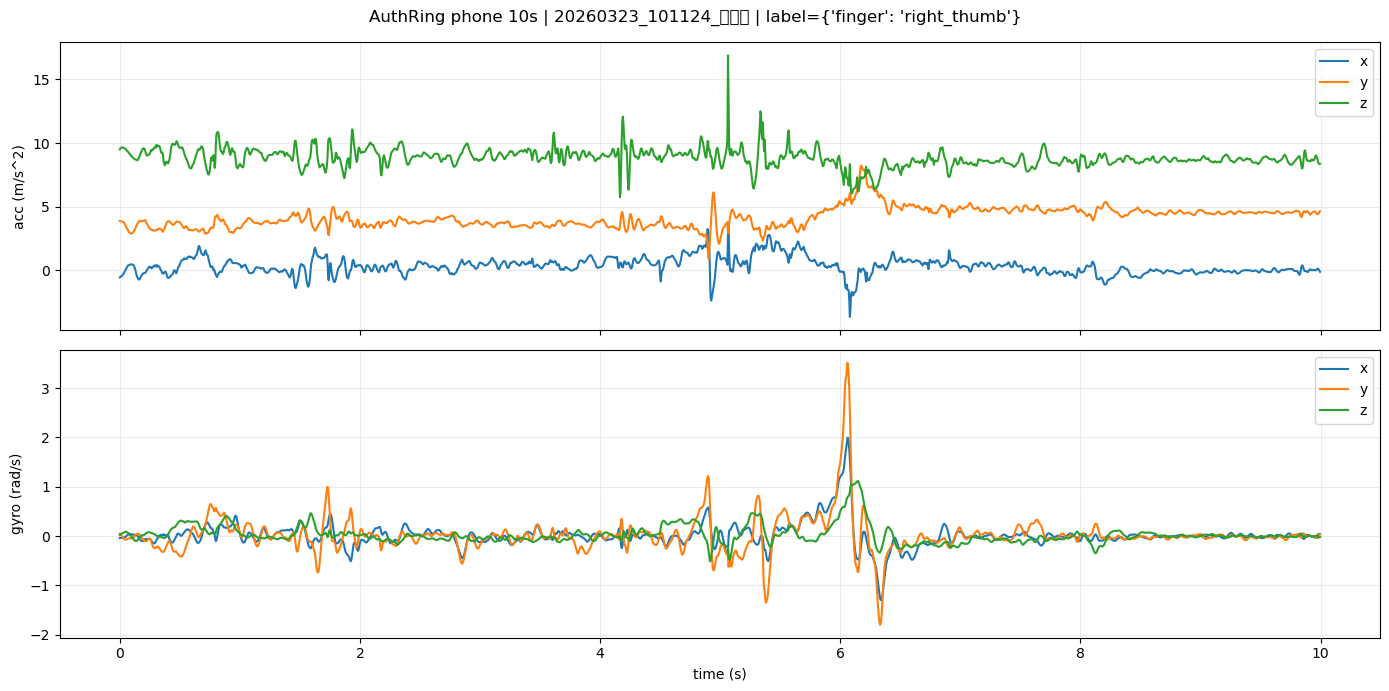

In [12]:
if not HAS_MATPLOTLIB:
    print('matplotlib is not installed; skip plotting. Install it with: %pip install matplotlib')
else:
    t = acc_seg[:, 0] / 1000.0

    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
    fig.suptitle(f'AuthRing phone {MODE} | {SESSION_DIR.name} | label={label}')

    axes[0].plot(t, acc_seg[:, 1], label='x')
    axes[0].plot(t, acc_seg[:, 2], label='y')
    axes[0].plot(t, acc_seg[:, 3], label='z')
    axes[0].set_ylabel('acc (m/s^2)')
    axes[0].legend(loc='upper right')
    axes[0].grid(True, alpha=0.25)

    axes[1].plot(t, gyro_seg[:, 1], label='x')
    axes[1].plot(t, gyro_seg[:, 2], label='y')
    axes[1].plot(t, gyro_seg[:, 3], label='z')
    axes[1].set_xlabel('time (s)')
    axes[1].set_ylabel('gyro (rad/s)')
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.25)

    plt.tight_layout()
    plt.show()

## 12. Preview Manifest Entry

这里只预览 manifest，不写文件。正式全量脚本后续应写入 `phone_10s.jsonl` / `phone_1000f.jsonl`。

In [13]:
def preview_manifest_entry(mode: str, filename: str, frames: int, duration_sec: float, label: dict) -> dict:
    return {
        'dir': f'sources/{SRC}/segments/{mode}/{DEVICE}/{filename}',
        'src': SRC,
        'device': DEVICE,
        'freq': FREQ,
        'mode': mode,
        'num_frames': frames,
        'duration_sec': duration_sec,
        'has_timestamp': True,
        'has_gyro': True,
        'label': label,
    }

entry = preview_manifest_entry(MODE, '00000001.npz', MODES[MODE]['frames'], MODES[MODE]['duration_sec'], label)
print(json.dumps(entry, ensure_ascii=False, indent=2))

{
  "dir": "sources/authring/segments/10s/phone/00000001.npz",
  "src": "authring",
  "device": "phone",
  "freq": 200.0,
  "mode": "10s",
  "num_frames": 2000,
  "duration_sec": 10.0,
  "has_timestamp": true,
  "has_gyro": true,
  "label": {
    "finger": "right_thumb"
  }
}


## 13. One-Session Wrapper

把上面的逻辑整理成一个单 session dry-run 函数。返回统计结果，不保存 `.npz`。

In [14]:
def process_one_phone_session_dry_run(session_dir: Path) -> dict:
    try:
        label = make_label(session_dir)
        acc_raw = read_phone_csv(session_dir, 'phone_acc.csv')
        gyro_raw = read_phone_csv(session_dir, 'phone_gyro.csv')

        acc_time, acc_xyz, acc_clean_stats = clean_phone_timeline(acc_raw)
        gyro_time, gyro_xyz, gyro_clean_stats = clean_phone_timeline(gyro_raw)

        acc_hz = average_hz(acc_time)
        gyro_hz = average_hz(gyro_time)
        if acc_hz < MIN_RAW_HZ or gyro_hz < MIN_RAW_HZ:
            raise SkipSession('raw average hz below 150')

        acc_bins, acc_counts, acc_valid = build_quality_bins(acc_time)
        gyro_bins, gyro_counts, gyro_valid = build_quality_bins(gyro_time)
        target_t = build_common_target_grid(acc_time, gyro_time)
        acc_interp = interpolate_xyz(acc_time, acc_xyz, target_t)
        gyro_interp = interpolate_xyz(gyro_time, gyro_xyz, target_t)

        acc_bin_idx = target_quality_index(target_t, acc_bins, acc_valid)
        gyro_bin_idx = target_quality_index(target_t, gyro_bins, gyro_valid)

        segments = {}
        for mode, spec in MODES.items():
            frames = spec['frames']
            candidate = 0
            saved = 0
            rejected = 0
            for start in range(0, len(target_t) - frames + 1, frames):
                end = start + frames
                candidate += 1
                ok = segment_is_valid(acc_bin_idx, acc_valid, start, end) and segment_is_valid(gyro_bin_idx, gyro_valid, start, end)
                if not ok:
                    rejected += 1
                    continue
                acc_seg, gyro_seg = build_npz_arrays(target_t, acc_interp, gyro_interp, start, end)
                if arrays_are_valid(acc_seg, gyro_seg, frames):
                    saved += 1
                else:
                    rejected += 1
            segments[mode] = {'candidate': candidate, 'saved': saved, 'rejected': rejected}

        return {
            'ok': True,
            'skip_reason': None,
            'session': str(session_dir),
            'label': label,
            'segments': segments,
            'stats': {
                'acc_hz': acc_hz,
                'gyro_hz': gyro_hz,
                'target_frames': len(target_t),
                'acc_clean': acc_clean_stats,
                'gyro_clean': gyro_clean_stats,
                'acc_valid_bin_ratio': float(np.mean(acc_valid)),
                'gyro_valid_bin_ratio': float(np.mean(gyro_valid)),
            },
        }
    except SkipSession as exc:
        return {
            'ok': False,
            'skip_reason': str(exc),
            'session': str(session_dir),
            'label': None,
            'segments': {'10s': {'candidate': 0, 'saved': 0, 'rejected': 0}, '1000f': {'candidate': 0, 'saved': 0, 'rejected': 0}},
            'stats': {},
        }

one_result = process_one_phone_session_dry_run(SESSION_DIR)
print(json.dumps(one_result, ensure_ascii=False, indent=2)[:4000])

{
  "ok": true,
  "skip_reason": null,
  "session": "/Volumes/Felix_Backups/Root26.5.22/科研与科创/数据记录/AuthRing/Dataset/丁涵琪/20260323_101124_丁涵琪",
  "label": {
    "finger": "right_thumb"
  },
  "segments": {
    "10s": {
      "candidate": 114,
      "saved": 113,
      "rejected": 1
    },
    "1000f": {
      "candidate": 228,
      "saved": 227,
      "rejected": 1
    }
  },
  "stats": {
    "acc_hz": 198.50820704861232,
    "gyro_hz": 198.565953872537,
    "target_frames": 228584,
    "acc_clean": {
      "original_rows": 226879,
      "unique_rows": 226879,
      "dropped_duplicate_rows": 0,
      "start_ms": 345442933.0,
      "end_ms": 346585853.0,
      "median_dt_ms": 5.0,
      "mean_dt_ms": 5.037597298988884
    },
    "gyro_clean": {
      "original_rows": 226945,
      "unique_rows": 226945,
      "dropped_duplicate_rows": 0,
      "start_ms": 345442933.0,
      "end_ms": 346585853.0,
      "median_dt_ms": 5.0,
      "mean_dt_ms": 5.036132261703328
    },
    "acc_valid_bin_r

## 14. Dataset-Level Dry Run Preview

先跑前 `N` 个 session 做统计，不保存数据。确认结果合理后，再把逻辑整理成全量 phone 处理脚本。

In [15]:
N = 20
dry_run_sessions = all_sessions[:N]

results = []
for i, session_dir in enumerate(dry_run_sessions, start=1):
    result = process_one_phone_session_dry_run(session_dir)
    results.append(result)
    if result['ok']:
        print(f"[{i}/{N}] OK {session_dir.name} 10s={result['segments']['10s']['saved']} 1000f={result['segments']['1000f']['saved']}")
    else:
        print(f"[{i}/{N}] SKIP {session_dir.name} {result['skip_reason']}")

skip_reasons = Counter(r['skip_reason'] for r in results if not r['ok'])
total_10s = sum(r['segments']['10s']['saved'] for r in results)
total_1000f = sum(r['segments']['1000f']['saved'] for r in results)

print('\nsummary')
print('ok sessions:', sum(r['ok'] for r in results))
print('skipped sessions:', sum(not r['ok'] for r in results))
print('skip reasons:', dict(skip_reasons))
print('saved 10s:', total_10s)
print('saved 1000f:', total_1000f)

[1/20] OK 20260323_101124_丁涵琪 10s=113 1000f=227
[2/20] OK 20260323_103607_丁涵琪 10s=98 1000f=197
[3/20] OK 20260323_111045_丁涵琪 10s=92 1000f=185
[4/20] OK 20260323_112913_丁涵琪 10s=89 1000f=179
[5/20] OK 20260323_114711_丁涵琪 10s=84 1000f=169
[6/20] OK 20260401_084400_丁雅晴 10s=138 1000f=278
[7/20] OK 20260401_091006_丁雅晴 10s=126 1000f=253
[8/20] OK 20260401_093412_丁雅晴 10s=126 1000f=253
[9/20] OK 20260401_100322_丁雅晴 10s=123 1000f=247
[10/20] OK 20260401_102837_丁雅晴 10s=123 1000f=246
[11/20] OK 20260327_083440_仇丽倩 10s=278 1000f=558
[12/20] OK 20260327_092435_仇丽倩 10s=129 1000f=258
[13/20] OK 20260327_094857_仇丽倩 10s=158 1000f=318
[14/20] OK 20260327_101943_仇丽倩 10s=138 1000f=277
[15/20] OK 20260327_104557_仇丽倩 10s=134 1000f=270
[16/20] OK 20260401_155631_任素杭 10s=105 1000f=211
[17/20] OK 20260401_161713_任素杭 10s=94 1000f=189
[18/20] OK 20260401_163538_任素杭 10s=92 1000f=184
[19/20] OK 20260401_165352_任素杭 10s=86 1000f=173
[20/20] OK 20260401_171200_任素杭 10s=87 1000f=176

summary
ok sessions: 20
skipped sess